In [1]:
# -*- coding: utf-8 -*-
"""
2×4 美化版柱状图 + 置信区间 + 主控因素标记
- 行：CLASSIC / LPJ-GUESS
- 列：HW / HD / CW / CD
- 每组双柱：左 P、右 LAI（PAWN median）
- 置信区间来自 bootstrap 结果
- 主控因素来自 dominant_factors_pawn.csv，用星号标在对应柱子上方（不遮挡数字）
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D

# ========= 0. 文件路径 =========
classic_csv       = "./importance_output/longtearm/classic_gsa_by_zone.csv"
lpj_csv           = "./importance_output/longtearm/lpj_gsa_by_zone.csv"
classic_boot_csv  = "./importance_output/longtearm/bootstrap_results/classic_bootstrap_results.csv"
lpj_boot_csv      = "./importance_output/longtearm/bootstrap_results/lpj_bootstrap_results.csv"
classic_dom_csv   = "./importance_output/longtearm/classic_dominant_factors_pawn.csv"
lpj_dom_csv       = "./importance_output/longtearm/lpj_dominant_factors_pawn.csv"

# ========= 1. 读入数据 =========
# 主数据（PAWN median，用来画柱）
cols_keep = ["Output", "Input", "PAWN_median", "Zone"]
classic_df = pd.read_csv(classic_csv)[cols_keep]
lpj_df     = pd.read_csv(lpj_csv)[cols_keep]

# bootstrap 结果（置信区间）
boot_keep = ["Zone", "Output", "Input", "pawn_ci_lower", "pawn_ci_upper"]
classic_boot = pd.read_csv(classic_boot_csv)[boot_keep]
lpj_boot     = pd.read_csv(lpj_boot_csv)[boot_keep]

# 主控因素结果
# 列：Zone,Output,Dominant_Factor,Precip_Value,LAI_Value,Dominance_Ratio
classic_dom = pd.read_csv(classic_dom_csv)
lpj_dom     = pd.read_csv(lpj_dom_csv)

# ========= 2. 配置 =========
zones = ["HW", "HD", "CW", "CD"]
zone_titles = {
    "HW": "Warm–Wet",
    "HD": "Warm–Dry",
    "CW": "Cold–Wet",
    "CD": "Cold–Dry",
}
x_labels    = ["ET", "T", "E_veg", "E_soil"]
label_order = ["evapotrans", "tran", "evspsblveg", "evspsblsoi"]

# P：蓝色系
blues = ["#08306b", "#2171b5", "#6baed6", "#c6dbef"]
# LAI：红色系
reds  = ["#67000d", "#cb181d", "#fb6a4a", "#fcbba1"]

mpl.rcParams.update({
    "axes.linewidth": 1.0,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})
plt.style.use("seaborn-v0_8-whitegrid")

# ========= 3. 画布 =========
fig, axes = plt.subplots(2, 4, figsize=(12, 6.5), sharey=True)
plt.subplots_adjust(wspace=0.25, hspace=0.35)

bar_width   = 0.35
x           = np.arange(len(label_order))
y_min, y_max = 0.0, 1.0
num_offset  = 0.015   # 数字离柱顶的距离
star_offset = 0.08    # 星号再比数字高一点

# ========= 4. 绘图主循环 =========
for row, (df, boot_df, dom_df, model_name) in enumerate(
    [
        (classic_df, classic_boot, classic_dom, "CLASSIC"),
        (lpj_df,     lpj_boot,     lpj_dom,     "LPJ-GUESS"),
    ]
):
    for col, zone in enumerate(zones):
        ax = axes[row, col]

        sub      = df[df["Zone"] == zone]
        boot_sub = boot_df[boot_df["Zone"] == zone]
        dom_sub  = dom_df[dom_df["Zone"] == zone]

        # pivot: index=Output, columns=Input, values=PAWN_median
        pivot = sub.pivot(index="Output", columns="Input", values="PAWN_median")

        # 背景
        ax.set_facecolor("#f9f9f9")

        for k, out in enumerate(label_order):
            xc = x[k]

            # 这一行的主控信息（可能为空）
            dom_row = dom_sub[dom_sub["Output"] == out]
            dominant_factor = dom_row["Dominant_Factor"].iloc[0] if not dom_row.empty else None
            dom_factor_lower = dominant_factor.lower() if dominant_factor is not None else ""

            # ---- P 柱 ----
            if ("precipitation" in pivot.columns) and (out in pivot.index):
                p_val = pivot.loc[out, "precipitation"]

                # 柱
                ax.bar(
                    xc - bar_width/2,
                    p_val,
                    width=bar_width,
                    color=blues[k],
                    edgecolor="black",
                    linewidth=0.5,
                    zorder=2,
                )
                # 数值
                ax.text(
                    xc - bar_width/2,
                    p_val + num_offset,
                    f"{p_val:.2f}",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                    color="black",
                    zorder=3,
                )

                # CI
                ci_p = boot_sub[
                    (boot_sub["Output"] == out) &
                    (boot_sub["Input"] == "precipitation")
                ]
                if not ci_p.empty:
                    lower = ci_p["pawn_ci_lower"].iloc[0]
                    upper = ci_p["pawn_ci_upper"].iloc[0]
                    yerr  = [[p_val - lower], [upper - p_val]]
                    ax.errorbar(
                        xc - bar_width/2,
                        p_val,
                        yerr=yerr,
                        fmt="none",
                        ecolor="black",
                        elinewidth=0.8,
                        capsize=3,
                        capthick=0.8,
                        zorder=4,
                    )
            else:
                p_val = None

            # ---- LAI 柱 ----
            if ("lai" in pivot.columns) and (out in pivot.index):
                l_val = pivot.loc[out, "lai"]
                ax.bar(
                    xc + bar_width/2,
                    l_val,
                    width=bar_width,
                    color=reds[k],
                    edgecolor="black",
                    linewidth=0.5,
                    zorder=2,
                )
                ax.text(
                    xc + bar_width/2,
                    l_val + num_offset,
                    f"{l_val:.2f}",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                    color="black",
                    zorder=3,
                )

                ci_l = boot_sub[
                    (boot_sub["Output"] == out) &
                    (boot_sub["Input"] == "lai")
                ]
                if not ci_l.empty:
                    lower = ci_l["pawn_ci_lower"].iloc[0]
                    upper = ci_l["pawn_ci_upper"].iloc[0]
                    yerr  = [[l_val - lower], [upper - l_val]]
                    ax.errorbar(
                        xc + bar_width/2,
                        l_val,
                        yerr=yerr,
                        fmt="none",
                        ecolor="black",
                        elinewidth=0.8,
                        capsize=3,
                        capthick=0.8,
                        zorder=4,
                    )
            else:
                l_val = None

            # ---- 主控因素星号（放在数字上方，不遮挡） ----
            if dominant_factor is not None:
                if "precip" in dom_factor_lower and p_val is not None:
                    x_dom = xc - bar_width/2
                    y_dom = p_val
                    star_color = blues[k]   # P 主导：用蓝色星
                elif "lai" in dom_factor_lower and l_val is not None:
                    x_dom = xc + bar_width/2
                    y_dom = l_val
                    star_color = reds[k]    # LAI 主导：用红色星
                else:
                    x_dom, y_dom, star_color = None, None, None

                if x_dom is not None:
                    y_star = y_dom + num_offset + star_offset
                    # 防止超过 y_max
                    y_star = min(y_star, y_max - 0.02)
                    ax.scatter(
                        x_dom,
                        y_star,
                        marker="*",
                        s=40,
                        color=star_color,
                        edgecolors="black",
                        linewidths=0.4,
                        alpha=0.9,
                        zorder=6,
                    )

        # ==== 坐标样式 ====
        ax.set_xticks(x)
        ax.set_ylim(y_min, y_max)
        ax.tick_params(axis="both", direction="in", length=4, width=0.8)

        # 第一行不显示 x 轴刻度文字；第二行显示
        if row == 0:
            ax.set_xticklabels([])
        else:
            ax.set_xticklabels(x_labels)

        # y 轴
        if col == 0:
            ax.set_ylabel("PAWN index (median)")
        else:
            ax.set_ylabel("")

        # 内嵌标题
        ax.text(
            0.85,
            0.9,
            f"{model_name}\n{zone_titles[zone]}",
            transform=ax.transAxes,
            fontsize=8.5,
            fontweight="bold",
            bbox=dict(
                facecolor="white",
                edgecolor="black",
                boxstyle="round,pad=0.3"
            ),
            ha="center",
            va="center",
            zorder=5,
        )

        # 边框
        for spine in ax.spines.values():
            spine.set_color("black")
            spine.set_linewidth(0.8)

        # 在y轴上标记 0.1、0.3、0.5
        ax.axhline(y=0.1, color="#006400", linestyle="--", lw=1)
        ax.axhline(y=0.3, color="#228B22", linestyle="--", lw=1)
        ax.axhline(y=0.5, color="#32CD32", linestyle="--", lw=1)

# ========= 5. 图例 =========
disp_labels = ["ET", "T", "E_veg", "E_soil"]

legend_handles = []
# P 系列（蓝）
for lbl, color in zip(disp_labels, blues):
    legend_handles.append(
        Line2D([], [], color=color, marker="s", linestyle="None",
               markersize=8, label=f"P → {lbl}")
    )
# LAI 系列（红）
for lbl, color in zip(disp_labels, reds):
    legend_handles.append(
        Line2D([], [], color=color, marker="s", linestyle="None",
               markersize=8, label=f"LAI → {lbl}")
    )
# 主控星号（用黑边星作为示例）
legend_handles.append(
    Line2D([], [], color="white", marker="*", markerfacecolor="gray",
           markeredgecolor="black", linestyle="None", markersize=9,
           label="Dominant factor")
)

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=9,                 # 8 个箭头 + 1 个星
    frameon=False,
    fontsize=9,
    bbox_to_anchor=(0.5, 0.01),
)

# ========= 6. 总标题 =========
fig.suptitle(
    "PAWN median sensitivity of P and LAI to ET components\n"
    "(with bootstrap 95% CI and dominant factor per component)",
    fontsize=14,
    y=0.92,
)

plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: './importance_output/longtearm/classic_bootstrap_results.csv'

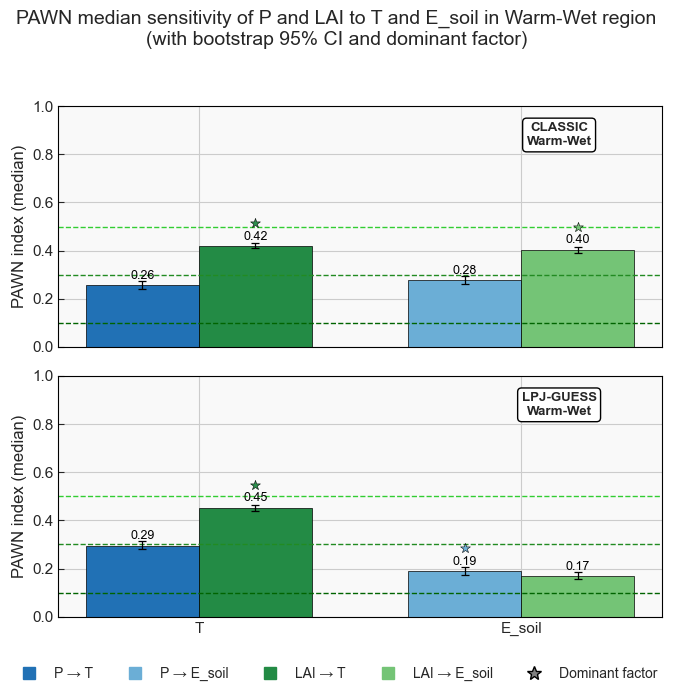

In [2]:
# -*- coding: utf-8 -*-
"""
WW(HW) 区域专用柱状图 + 置信区间 + 主控因素标记
- 行：CLASSIC / LPJ-GUESS
- 仅一个区域：HW（Warm-Wet）
- 仅两个输出：T / E_soil
- 每组双柱：左 P、右 LAI（PAWN median）
- 置信区间来自 bootstrap 结果
- 主控因素来自 dominant_factors_pawn.csv，用星号标在对应柱子上方
- P：蓝色系
- LAI：绿色系
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D

# ========= 0. 文件路径 =========
classic_csv       = "./importance_output/longtearm/classic_gsa_by_zone.csv"
lpj_csv           = "./importance_output/longtearm/lpj_gsa_by_zone.csv"
classic_boot_csv  = "./importance_output/longtearm/bootstrap_results/classic_bootstrap_results.csv"
lpj_boot_csv      = "./importance_output/longtearm/bootstrap_results/lpj_bootstrap_results.csv"
classic_dom_csv   = "./importance_output/longtearm/classic_dominant_factors_pawn.csv"
lpj_dom_csv       = "./importance_output/longtearm/lpj_dominant_factors_pawn.csv"

# ========= 1. 读入数据 =========
cols_keep = ["Output", "Input", "PAWN_median", "Zone"]
classic_df = pd.read_csv(classic_csv)[cols_keep]
lpj_df     = pd.read_csv(lpj_csv)[cols_keep]

boot_keep = ["Zone", "Output", "Input", "pawn_ci_lower", "pawn_ci_upper"]
classic_boot = pd.read_csv(classic_boot_csv)[boot_keep]
lpj_boot     = pd.read_csv(lpj_boot_csv)[boot_keep]

classic_dom = pd.read_csv(classic_dom_csv)
lpj_dom     = pd.read_csv(lpj_dom_csv)

# ========= 2. 配置 =========
zone = "HW"
zone_title = "Warm-Wet"

# 只保留 T 和 E_soil
x_labels    = ["T", "E_soil"]
label_order = ["tran", "evspsblsoi"]

# P：蓝色系（对应 T, E_soil）
blues = ["#2171b5", "#6baed6"]

# LAI：绿色系（对应 T, E_soil）
greens = ["#238b45", "#74c476"]

mpl.rcParams.update({
    "axes.linewidth": 1.0,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})
plt.style.use("seaborn-v0_8-whitegrid")

# ========= 3. 画布 =========
fig, axes = plt.subplots(2, 1, figsize=(6.8, 7.2), sharey=True)
plt.subplots_adjust(wspace=0.2, hspace=0.35)

bar_width   = 0.35
x           = np.arange(len(label_order))
y_min, y_max = 0.0, 1.0
num_offset  = 0.015
star_offset = 0.08

# ========= 4. 绘图主循环 =========
for row, (df, boot_df, dom_df, model_name) in enumerate(
    [
        (classic_df, classic_boot, classic_dom, "CLASSIC"),
        (lpj_df,     lpj_boot,     lpj_dom,     "LPJ-GUESS"),
    ]
):
    ax = axes[row]

    sub      = df[df["Zone"] == zone]
    boot_sub = boot_df[boot_df["Zone"] == zone]
    dom_sub  = dom_df[dom_df["Zone"] == zone]

    pivot = sub.pivot(index="Output", columns="Input", values="PAWN_median")

    ax.set_facecolor("#f9f9f9")

    for k, out in enumerate(label_order):
        xc = x[k]

        dom_row = dom_sub[dom_sub["Output"] == out]
        dominant_factor = dom_row["Dominant_Factor"].iloc[0] if not dom_row.empty else None
        dom_factor_lower = dominant_factor.lower() if dominant_factor is not None else ""

        # ---- P 柱 ----
        if ("precipitation" in pivot.columns) and (out in pivot.index):
            p_val = pivot.loc[out, "precipitation"]

            ax.bar(
                xc - bar_width/2,
                p_val,
                width=bar_width,
                color=blues[k],
                edgecolor="black",
                linewidth=0.5,
                zorder=2,
            )
            ax.text(
                xc - bar_width/2,
                p_val + num_offset,
                f"{p_val:.2f}",
                ha="center",
                va="bottom",
                fontsize=9,
                color="black",
                zorder=3,
            )

            ci_p = boot_sub[
                (boot_sub["Output"] == out) &
                (boot_sub["Input"] == "precipitation")
            ]
            if not ci_p.empty:
                lower = ci_p["pawn_ci_lower"].iloc[0]
                upper = ci_p["pawn_ci_upper"].iloc[0]
                yerr  = [[p_val - lower], [upper - p_val]]
                ax.errorbar(
                    xc - bar_width/2,
                    p_val,
                    yerr=yerr,
                    fmt="none",
                    ecolor="black",
                    elinewidth=0.9,
                    capsize=3,
                    capthick=0.9,
                    zorder=4,
                )
        else:
            p_val = None

        # ---- LAI 柱 ----
        if ("lai" in pivot.columns) and (out in pivot.index):
            l_val = pivot.loc[out, "lai"]

            ax.bar(
                xc + bar_width/2,
                l_val,
                width=bar_width,
                color=greens[k],
                edgecolor="black",
                linewidth=0.5,
                zorder=2,
            )
            ax.text(
                xc + bar_width/2,
                l_val + num_offset,
                f"{l_val:.2f}",
                ha="center",
                va="bottom",
                fontsize=9,
                color="black",
                zorder=3,
            )

            ci_l = boot_sub[
                (boot_sub["Output"] == out) &
                (boot_sub["Input"] == "lai")
            ]
            if not ci_l.empty:
                lower = ci_l["pawn_ci_lower"].iloc[0]
                upper = ci_l["pawn_ci_upper"].iloc[0]
                yerr  = [[l_val - lower], [upper - l_val]]
                ax.errorbar(
                    xc + bar_width/2,
                    l_val,
                    yerr=yerr,
                    fmt="none",
                    ecolor="black",
                    elinewidth=0.9,
                    capsize=3,
                    capthick=0.9,
                    zorder=4,
                )
        else:
            l_val = None

        # ---- 主控因素星号 ----
        if dominant_factor is not None:
            if "precip" in dom_factor_lower and p_val is not None:
                x_dom = xc - bar_width/2
                y_dom = p_val
                star_color = blues[k]
            elif "lai" in dom_factor_lower and l_val is not None:
                x_dom = xc + bar_width/2
                y_dom = l_val
                star_color = greens[k]
            else:
                x_dom, y_dom, star_color = None, None, None

            if x_dom is not None:
                y_star = min(y_dom + num_offset + star_offset, y_max - 0.02)
                ax.scatter(
                    x_dom,
                    y_star,
                    marker="*",
                    s=55,
                    color=star_color,
                    edgecolors="black",
                    linewidths=0.4,
                    alpha=0.95,
                    zorder=6,
                )

    # ==== 坐标样式 ====
    ax.set_xticks(x)
    ax.set_ylim(y_min, y_max)
    ax.tick_params(axis="both", direction="in", length=4, width=0.8)

    if row == 0:
        ax.set_xticklabels([])
    else:
        ax.set_xticklabels(x_labels)

    ax.set_ylabel("PAWN index (median)")

    # 内嵌标题
    ax.text(
        0.83,
        0.88,
        f"{model_name}\n{zone_title}",
        transform=ax.transAxes,
        fontsize=9.5,
        fontweight="bold",
        bbox=dict(
            facecolor="white",
            edgecolor="black",
            boxstyle="round,pad=0.3"
        ),
        ha="center",
        va="center",
        zorder=5,
    )

    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(0.8)

    # 参考线
    ax.axhline(y=0.1, color="#006400", linestyle="--", lw=1)
    ax.axhline(y=0.3, color="#228B22", linestyle="--", lw=1)
    ax.axhline(y=0.5, color="#32CD32", linestyle="--", lw=1)

# ========= 5. 图例 =========
legend_handles = [
    Line2D([], [], color=blues[0], marker="s", linestyle="None",
           markersize=8, label="P → T"),
    Line2D([], [], color=blues[1], marker="s", linestyle="None",
           markersize=8, label="P → E_soil"),
    Line2D([], [], color=greens[0], marker="s", linestyle="None",
           markersize=8, label="LAI → T"),
    Line2D([], [], color=greens[1], marker="s", linestyle="None",
           markersize=8, label="LAI → E_soil"),
    Line2D([], [], color="white", marker="*", markerfacecolor="gray",
           markeredgecolor="black", linestyle="None", markersize=10,
           label="Dominant factor")
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=5,
    frameon=False,
    fontsize=10,
    bbox_to_anchor=(0.5, 0.01),
)

# ========= 6. 总标题 =========
fig.suptitle(
    "PAWN median sensitivity of P and LAI to T and E_soil in Warm-Wet region\n"
    "(with bootstrap 95% CI and dominant factor)",
    fontsize=14,
    y=0.96,
)

plt.tight_layout(rect=[0, 0.07, 1, 0.93])
plt.show()

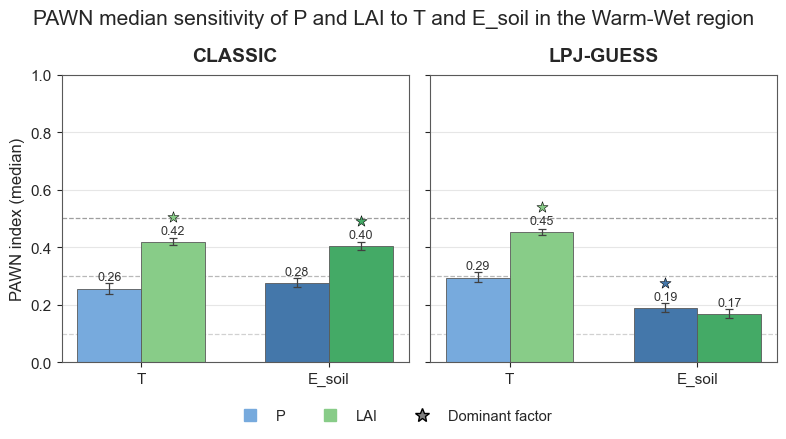

In [7]:
# -*- coding: utf-8 -*-
"""
PPT-friendly bar plot for HW only
- Layout: 1×2 (CLASSIC, LPJ-GUESS)
- Outputs: T, E_soil
- Left bar: P
- Right bar: LAI
- 95% CI from bootstrap
- Dominant factor shown as star
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D



# ========= 1. 读入数据 =========
cols_keep = ["Output", "Input", "PAWN_median", "Zone"]
classic_df = pd.read_csv(classic_csv)[cols_keep]
lpj_df     = pd.read_csv(lpj_csv)[cols_keep]

boot_keep = ["Zone", "Output", "Input", "pawn_ci_lower", "pawn_ci_upper"]
classic_boot = pd.read_csv(classic_boot_csv)[boot_keep]
lpj_boot     = pd.read_csv(lpj_boot_csv)[boot_keep]

classic_dom = pd.read_csv(classic_dom_csv)
lpj_dom     = pd.read_csv(lpj_dom_csv)

# ========= 2. 配置 =========
zone = "HW"
zone_title = "Warm-Wet"

x_labels    = ["T", "E_soil"]
label_order = ["tran", "evspsblsoi"]

# 更柔和一点的颜色
p_colors   = ["#77AADD", "#4477AA"]   # 蓝色系
lai_colors = ["#88CC88", "#44AA66"]   # 绿色系

mpl.rcParams.update({
    "axes.linewidth": 0.9,
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "font.size": 11,
})
plt.style.use("seaborn-v0_8-whitegrid")

# ========= 3. 画布 =========
fig, axes = plt.subplots(1, 2, figsize=(8, 4.8), sharey=True)
plt.subplots_adjust(wspace=0.18)

bar_width   = 0.34
x           = np.arange(len(label_order))
y_min, y_max = 0.0, 1.0
num_offset  = 0.018
star_offset = 0.07

# ========= 4. 绘图 =========
for ax, (df, boot_df, dom_df, model_name) in zip(
    axes,
    [
        (classic_df, classic_boot, classic_dom, "CLASSIC"),
        (lpj_df,     lpj_boot,     lpj_dom,     "LPJ-GUESS"),
    ]
):
    sub      = df[df["Zone"] == zone]
    boot_sub = boot_df[boot_df["Zone"] == zone]
    dom_sub  = dom_df[dom_df["Zone"] == zone]

    pivot = sub.pivot(index="Output", columns="Input", values="PAWN_median")

    ax.set_facecolor("white")

    for k, out in enumerate(label_order):
        xc = x[k]

        dom_row = dom_sub[dom_sub["Output"] == out]
        dominant_factor = dom_row["Dominant_Factor"].iloc[0] if not dom_row.empty else None
        dom_factor_lower = dominant_factor.lower() if dominant_factor is not None else ""

        # ---- P ----
        if ("precipitation" in pivot.columns) and (out in pivot.index):
            p_val = pivot.loc[out, "precipitation"]

            ax.bar(
                xc - bar_width/2,
                p_val,
                width=bar_width,
                color=p_colors[k],
                edgecolor="0.35",
                linewidth=0.6,
                zorder=2,
            )

            ax.text(
                xc - bar_width/2,
                p_val + num_offset,
                f"{p_val:.2f}",
                ha="center",
                va="bottom",
                fontsize=9,
                color="0.2",
                zorder=4,
            )

            ci_p = boot_sub[
                (boot_sub["Output"] == out) &
                (boot_sub["Input"] == "precipitation")
            ]
            if not ci_p.empty:
                lower = ci_p["pawn_ci_lower"].iloc[0]
                upper = ci_p["pawn_ci_upper"].iloc[0]
                yerr  = [[p_val - lower], [upper - p_val]]
                ax.errorbar(
                    xc - bar_width/2,
                    p_val,
                    yerr=yerr,
                    fmt="none",
                    ecolor="0.25",
                    elinewidth=0.9,
                    capsize=3,
                    capthick=0.9,
                    zorder=5,
                )
        else:
            p_val = None

        # ---- LAI ----
        if ("lai" in pivot.columns) and (out in pivot.index):
            l_val = pivot.loc[out, "lai"]

            ax.bar(
                xc + bar_width/2,
                l_val,
                width=bar_width,
                color=lai_colors[k],
                edgecolor="0.35",
                linewidth=0.6,
                zorder=2,
            )

            ax.text(
                xc + bar_width/2,
                l_val + num_offset,
                f"{l_val:.2f}",
                ha="center",
                va="bottom",
                fontsize=9,
                color="0.2",
                zorder=4,
            )

            ci_l = boot_sub[
                (boot_sub["Output"] == out) &
                (boot_sub["Input"] == "lai")
            ]
            if not ci_l.empty:
                lower = ci_l["pawn_ci_lower"].iloc[0]
                upper = ci_l["pawn_ci_upper"].iloc[0]
                yerr  = [[l_val - lower], [upper - l_val]]
                ax.errorbar(
                    xc + bar_width/2,
                    l_val,
                    yerr=yerr,
                    fmt="none",
                    ecolor="0.25",
                    elinewidth=0.9,
                    capsize=3,
                    capthick=0.9,
                    zorder=5,
                )
        else:
            l_val = None

        # ---- dominant star ----
        if dominant_factor is not None:
            if "precip" in dom_factor_lower and p_val is not None:
                x_dom = xc - bar_width/2
                y_dom = p_val
                star_color = p_colors[k]
            elif "lai" in dom_factor_lower and l_val is not None:
                x_dom = xc + bar_width/2
                y_dom = l_val
                star_color = lai_colors[k]
            else:
                x_dom, y_dom, star_color = None, None, None

            if x_dom is not None:
                y_star = min(y_dom + num_offset + star_offset, y_max - 0.025)
                ax.scatter(
                    x_dom,
                    y_star,
                    marker="*",
                    s=70,
                    color=star_color,
                    edgecolors="black",
                    linewidths=0.4,
                    zorder=6,
                )

    # ---- 样式 ----
    ax.set_title(model_name, pad=10, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.set_ylim(y_min, y_max)
    ax.tick_params(axis="both", direction="out", length=3.5, width=0.8)

    # 只保留一条淡参考线
    ax.axhline(y=0.1, color="0.82", linestyle="--", lw=0.9, zorder=1)
    ax.axhline(y=0.3, color="0.72", linestyle="--", lw=0.9, zorder=1)
    ax.axhline(y=0.5, color="0.62", linestyle="--", lw=0.9, zorder=1)

    # 网格更轻
    ax.grid(axis="y", color="0.9", linewidth=0.8)
    ax.grid(axis="x", visible=False)

    for spine in ax.spines.values():
        spine.set_color("0.35")
        spine.set_linewidth(0.8)

axes[0].set_ylabel("PAWN index (median)")
axes[1].set_ylabel("")

# ========= 5. 图例 =========
legend_handles = [
    Line2D([], [], color=p_colors[0], marker="s", linestyle="None",
           markersize=8, label="P"),
    Line2D([], [], color=lai_colors[0], marker="s", linestyle="None",
           markersize=8, label="LAI"),
    Line2D([], [], color="white", marker="*", markerfacecolor="gray",
           markeredgecolor="black", linestyle="None", markersize=10,
           label="Dominant factor"),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=3,
    frameon=False,
    fontsize=10.5,
    bbox_to_anchor=(0.5, 0.01),
)

# ========= 6. 总标题 =========
fig.suptitle(
    "PAWN median sensitivity of P and LAI to T and E_soil in the Warm-Wet region",
    fontsize=15,
    y=0.9,
)

plt.tight_layout(rect=[0, 0.08, 1, 0.93])
plt.show()